In [440]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as smp
from sympy.polys.polyfuncs import interpolate
from matplotlib.pyplot import figure
from scipy.interpolate import CubicSpline
from scipy.interpolate import PchipInterpolator
import ipywidgets as widgets
from ipywidgets import interact, interactive
from scipy.interpolate import UnivariateSpline
import scipy.stats as stats
from scipy.linalg import expm
from mpl_toolkits.mplot3d import Axes3D
from numpy import linalg as LA
from scipy.integrate import solve_ivp
import nodepy.linear_multistep_method as lm
from nodepy.ivp import IVP
from IPython.display import display, Math

## Задание 1. Неявный метод Эйлера.

Решите то же самое уравнение
$$\frac{du}{dt} = \lambda u,$$
используя неявную схему Эйлера. Сравните поведение неявной и явной схем Эйлера. Постройте решение для нескольких значений шага интегрирования, опишите поведение решения при $\lambda\tau > 2$.


$$
\frac{y_{n+1}-y_n}{\tau} = f(t_{n+1}, y_{n+1}) = \lambda y_{n+1}\\
y_{n+1} = \frac{y_n}{1-\tau\lambda}
$$

In [4]:
def explicit_euler_solve(lam, u0, T, dt):
    """Решает $du/dt = \lambda u$ на $0 < t < T$ с $u(t=0) = u0$ при помощи явного метода Эйлера."""
    num_steps = int(T/dt)
    tt = np.arange(num_steps+1)*dt
    y = np.empty(num_steps+1)
    y[0] = u0
    for k in range(num_steps):
        y[k+1] = y[k] + dt*lam*y[k]
    return tt, y

In [5]:
def implicit_euler_solve(lam, u0, T, dt):
    """Решает du/dt = lambda u на 0 < t < T с u(t=0) = u0 при помощи неявного метода Эйлера."""
    num_steps = int(T/dt)
    tt = np.arange(num_steps+1)*dt
    y = np.empty(num_steps+1)
    y[0] = u0
    for k in range(num_steps):
        y[k+1] = y[k]/(1-dt*lam)
    return tt, y

In [6]:
def on_change(lam, dt):
    funcs = [explicit_euler_solve, implicit_euler_solve]
    titles = ['Explicit euler solve', 'Implicit euler solve']
    
    w = 400
    h = 100
    DPI = 100
    
    plt.figure(1, figsize=(4*float(w)/DPI, 6*float(h)/DPI), dpi=DPI)
    
    for n in range(len(funcs)):
        tt, y = funcs[n](lam, u0=1.0, T=8/abs(lam), dt=dt)

        axes = plt.subplot(1, 2, n+1)
        
        axes.plot(tt, y, 'o--', label='numeric solution')
        axes.plot(tt, np.exp(lam*tt), '-', lw=2, label='ground truth')
        axes.legend(loc='best')
        axes.grid(True)
        axes.set_title(titles[n])

    print('lambda * tau =', lam*dt)
    
interact(on_change, lam=widgets.FloatSlider(value=-0.5, min=-5, max = 5, step=0.01), 
         dt=widgets.FloatSlider(value=1, min=0.1, max = 10, step=0.01))

interactive(children=(FloatSlider(value=-0.5, description='lam', max=5.0, min=-5.0, step=0.01), FloatSlider(va…

<function __main__.on_change(lam, dt)>

In [7]:
lam = -0.5 
tt, y = implicit_euler_solve(lam, u0=1.0, T=8/abs(lam), dt=2.1/abs(lam))

assert (y > 0).all()

Рассмотрим систему двух уравнений первого mпорядка.

$$\frac{d\mathbf{u}}{dt} = A \mathbf{u}$$

где $\mathbf{u}$ есть вектор длины 2, $A = const$ - заданная матрица 2 $\times$ 2.

## Задание 2. Сравнение явной схемы Эйлера и матричной экспоненты.

Выполните обобщение алгоритма `euler_solve` для решения систем линейных уравнений первого порядка с матрицей $A$, не зависящей от времени, используя явную схему Эйлера.

$$
\frac{\mathbf{y}_{n+1}-\mathbf{y}_n}{\tau} = A \mathbf{y}_n\\
\mathbf{y}_{n+1} = (\tau A+E)\mathbf{y}_n
$$

$$
\frac{d\mathbf{u}}{dt} = A\mathbf{u}; \quad A = S^TAS; \quad \mathbf{v} = S^T\mathbf{u}\\
v_k = e^{\lambda_k t} \quad \text{(если матрица диагонализуема)}\\
u_k = S_{kj}v_j; \quad \mathbf{u} = S\cdot(e^{\lambda_1t}, \dots, e^{\lambda_nt})^T = e^{At}S\cdot(1, \ldots, 1)^T\\
\mathbf{u} = e^{At}\mathbf{w}; \quad \mathbf{u}(0) = \mathbf{w}
$$

In [8]:
def euler_solve2(a, u0, T, dt):
    """Solve the system du/dt = Au via an explicit Euler scheme.
    
    Parameters
    ----------
    a : ndarray, shape(ndim, ndim)
        The matrix of the l.h.s.
    u0 : ndarray, shape(ndim,)
        Initial condition
    T : float
        construct the solution for $t\in [0, T)$
    dt : float
        Integration step size $\tau$
        
    Returns
    -------
    t : ndarray, shape (n,)
        Integration times
    y : ndarray, shape (n, ndim)
        Solution of the FD system. 
        y[k, :] is the solution at t[k].
    """
    a = np.asarray(a, dtype=float)
    u0 = np.asarray(u0, dtype=float)
    num_steps = int(T/dt)
    tt = np.arange(num_steps+1)*dt
    ndim = a.shape[0]
    
    y = np.empty((num_steps+1, ndim))
    y[0] = u0
    matrix = dt*a + np.eye(ndim)
    
    for k in range(num_steps):
        y[k+1] = np.matmul(matrix, y[k])
        
    return tt, y

In [9]:
def mat_exp_solve(a, u0, t):
    """Construct the solution of $du/dt = A u$ with $u(t=0) = u_0$ at times `tt`.
    
    Parameters
    ----------
    a : ndarray, shape (ndim, ndim)
    
    u0 : ndarray, shape (ndim,)
    
    tt : ndarray, shape (n,)
        The values of $t$
        
    Return
    ------
    u : ndarray, shape (n, ndim)
        u[:, k] is $\exp(t[k] A)$
    """
    
    num_steps = len(t)
    ndim = a.shape[0]
    
    u = np.empty((num_steps, ndim))
    
    for k in range(num_steps):
        u[k] = np.matmul(expm(a*t[k]), u0)
        
    return u

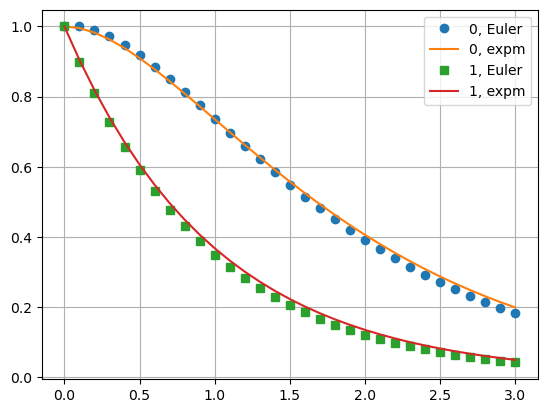

In [10]:
a = np.array([[-1, 1],
              [0, -1]], dtype=float)
t, y  = euler_solve2(a, u0=[1, 1], T=3, dt=0.1)
ym = mat_exp_solve(a, [1, 1], t)

plt.plot(t, y[:, 0], 'o', label='0, Euler')
plt.plot(t, ym[:, 0], '-', label='0, expm')

plt.plot(t, y[:, 1], 's', label='1, Euler')
plt.plot(t, ym[:, 1], '-', label='1, expm')

plt.legend(loc='best')
plt.grid(True)

Рассмотрим линейную систему, $du/dt = Au$, с матрицей правой части

$$
A = \begin{bmatrix} -10 & 10 \\ 32 & -499 \end{bmatrix}
$$

с начальным условием $\mathbf{u} = (1,0)^T$.

Система называется жесткой, если для всех $(x, \vec{y}(x))$ (на решениях системы) собственные значения матрицы Якоби системы $\mathbf{J}(x)$ (в данном случае она равна $A$) удовлетворяют условиям

$$
\max_j |\operatorname{Re} \lambda_j| / \min_k |\operatorname{Re} \lambda_k| \gg 1, \quad \operatorname{Re} \lambda_j < 0, \quad \max_j |\operatorname{Im} \lambda_j| \ll \max_k |\operatorname{Re} \lambda_k| \quad \forall j, k
$$

Число $s = \max_i |\operatorname{Re} \lambda_i| / \min_k |\operatorname{Re} \lambda_k|$ называется числом жесткости системы.

Пример.

Для решения задачи Коши системы ОДУ используется численный метод Рунге-Кутты, заданный таблицей Бутчера:
$$
\left.
\begin{aligned}
u' &= -800u + 4 \cdot 10^{-2}v + 2 \cdot 10^{-2}w, & u(0) = 0, \\
v' &= -5v - 3w, & v(0) = 4, \\
w' &= v - w, & w(0) = 6,
\end{aligned}
\right\}
\quad
\begin{array}{c|cc}
1/5 & 1/5 & 0 \\
4/5 & 3/5 & 1/5 \\
\hline
    & 1/2 & 1/2
\end{array}
$$

Получим для него функцию и условие устойчивости. Вычислим число жёсткости.

$$
R(z) = \frac{1 + \frac{3}{5}z + \left(\frac{1}{2} - \frac{2}{5} + \frac{1}{25}\right)z^2}{1 - \frac{2}{5}z + \frac{1}{25}z^2}
$$

Матрица $\mathbf{J}(x)$ (см. формулу (7.1.3)) постоянна и ее собственные значения $\lambda_1 = -2, \lambda_2 = -4, \lambda_3 = -800$ лежат на действительной оси. Так как $z_i = \lambda_i h$, то и функцию устойчивости достаточно исследовать на действительной оси.

Область устойчивости определяется из условия $|R(z)| \le 1$. Получаем

$$
\operatorname{Im} z_i = 0, \quad \operatorname{Re} z_i (1 + \operatorname{Re} z_i/10) \le 0, \quad i = 1, 2, 3
$$

Шаг интегрирования, который удовлетворяет всем условиям $h \in (0, 10/800]$.

Число жесткости $s = 800/2 = 400$.


# Задание 3. Проверка жёсткости системы и неявные методы.

Найдите собственные значения матрицы $A$ (используя np.linalg.eigvals) и прокомментируйте, является ли система жесткой.

Решите систему, используя фиксированный шаг

$$\tau = 0.01$$

Стабилен ли метод на шаге такого размера?

In [11]:
a = np.array([
    [-10, 10],
    [32, -499]
], dtype=float)

u0 = np.array([1, 0])

tau = 0.01

eig = np.linalg.eigvals(a)
s = max(abs(eig))/min(abs(eig))
z = eig*tau

R = np.empty(len(eig))
for i in range(len(eig)):
    R[i] = (1+0.6*z[i]+0.14*z[i]**2)/(1-0.4*z[i]+0.04*z[i]**2)

print(f"lambda={eig}")
print(f"s={s}")
print(f"z={z}")
print(f"R={R}")

lambda=[  -9.34647667 -499.65352333]
s=53.45902427704808
z=[-0.09346477 -4.99653523]
R=[0.91077571 0.37456698]


$$
53 \gg 1 \Rightarrow \text{система является жесткой}\\
|R| \leq 1 \Rightarrow \text{метод устойчив}
$$

$$
k_1 = A\left(y_n + \tau\left(\frac{1}{5}k_1\right)\right)\\
k_2 = A\left(y_n + \tau\left(\frac{3}{5}k_1 + \frac{1}{5}k_2\right)\right)\\
k_1 = \left(E - \frac{1}{5}\tau A \right)^{-1} \cdot A \cdot y_n\\
k_2 = \left(E - \frac{1}{5}\tau A \right)^{-1} \cdot A \cdot \left(y_n + \frac{3}{5}\tau k_1\right)\\
y_{n+1} = y_n + \frac{1}{2}\tau(k_1 + k_2)
$$

In [12]:
def Runge_Kutta(a, u0, T, dt):
    a = np.asarray(a, dtype=float)
    u0 = np.asarray(u0, dtype=float)
    num_steps = int(T/dt)
    tt = np.arange(num_steps+1)*dt
    ndim = a.shape[0]
    
    y = np.empty((num_steps+1, ndim))
    y[0] = u0
    
    matrix = np.matmul(np.linalg.inv(np.eye(ndim) -0.2*dt*a), a)
    
    for n in range(num_steps):
        k1 = np.matmul(matrix, y[n])
        k2 = np.matmul(matrix, y[n]+0.6*dt*k1)

        y[n+1] = y[n] + 0.5*dt*(k1+k2)
        
    return tt, y

Постройте графики решения системы на интервале $0 < t < 1$ с начальным условием $u = (1,0)^T$ используя функции euler_solve2 и mat_exp_solve. Используйте несколько значений шага, например $\tau = 4 \cdot 10^{-3}$ и $\tau = 4.5 \cdot 10^{-3}$. Прокомментируйте поведение решений.

Реализуйте неявную схему Эйлера для системы линейных уравнений первого порядка с постоянными коэффициентами. Заметьте, что на каждом шаге вам необходимо решать систему линейных алгебраических уравнений (используйте np.linalg.solve ).

Сравните решения, полученные явной и неявной схемами Эйлера.

$$
\frac{y_{n+1}-y_n}{\tau} = A y_{n+1}\\
y_{n+1} = (E-\tau A)^{-1} y_n
$$

In [13]:
def implicit_euler_solve2(a, u0, T, dt):
    a = np.asarray(a, dtype=float)
    u0 = np.asarray(u0, dtype=float)
    num_steps = int(T/dt)
    tt = np.arange(num_steps+1)*dt
    ndim = a.shape[0]
    
    y = np.empty((num_steps+1, ndim))
    y[0] = u0
    
    matrix = np.linalg.inv(np.eye(ndim)-dt*a)
    
    for n in range(num_steps):
        y[n+1] = np.matmul(matrix, y[n])
        
    return tt, y

In [14]:
def on_change(dt, power, runge_kutta=True, explicit_euler=True, implicit_euler=True, matrix_exp=True):
    T = 1
    tau = dt * 10**power

    print(f"tau={dt} 10^{power}")

    rkt, rky = Runge_Kutta(a, u0, T, tau)

    plt
    titles = ['y_0', 'y_1']

    w = 400
    h = 100
    DPI = 100

    plt.figure(1, figsize=(4*float(w)/DPI, 6*float(h)/DPI), dpi=DPI)

    tt, y = Runge_Kutta(a, u0, T, tau)
    
    if runge_kutta:
        for n in range(rky.shape[1]):
            axes = plt.subplot(1, 2, n+1)
            axes.plot(tt, y[:,n], '-', label=f'Runge-Kutta')
    
    if explicit_euler:
        tt, y = euler_solve2(a, u0, T, tau)
        for n in range(rky.shape[1]):
            axes = plt.subplot(1, 2, n+1)
            axes.plot(tt, y[:,n], 'o', label=f'Explisit Euler')

    if implicit_euler:
        tt, y = implicit_euler_solve2(a, u0, T, tau)
        for n in range(rky.shape[1]):
            axes = plt.subplot(1, 2, n+1)
            axes.plot(tt, y[:,n], 'x', label=f'Implicit Euler')

    if matrix_exp:
        y = mat_exp_solve(a, u0, tt)
        for n in range(rky.shape[1]):
            axes = plt.subplot(1, 2, n+1)
            axes.plot(tt, y[:,n], 's', label='Matrix exponent')
        

    for n in range(rky.shape[1]):
        axes = plt.subplot(1, 2, n+1)
        axes.legend(loc='best')
        axes.grid(True)
        axes.set_title(titles[n])

        
        
interact(on_change, dt=widgets.FloatSlider(value=1, min=1, max = 10, step=0.1),\
         power=widgets.IntSlider(value=-3, min=-4, max = 0, step=1))

interactive(children=(FloatSlider(value=1.0, description='dt', max=10.0, min=1.0), IntSlider(value=-3, descrip…

<function __main__.on_change(dt, power, runge_kutta=True, explicit_euler=True, implicit_euler=True, matrix_exp=True)>

# Задача Коши для ОДУ второго порядка.

Рассмотрим ОДУ второго порядка, описывающее осцилляции маятника

$$\frac{d^2u}{dt^2} + \omega^2u = 0$$

# Задание 6. Законы сохранения и решение ОДУ.

Преобразуйте данное уравнение второго порядка в систему ОДУ первого порядка.

Решите данную систему уравнений, используя явную схему Эйлера на интервале времени не менее десяти периодов осцилляций.

Мы знаем, что в отсутствии трения выполняется закон сохранения энергии:

$$ E = \frac{(du/dt)^2}{2} + \frac{\omega^2u^2}{2} $$

Постройте зависимость 
 от времени для вашего численного решения. Используйте несколько значений шага. Выполняется ли закон сохранения энергии?

$$
\frac{d}{dt} u = u'\\
\frac{d}{dt} u' = -\omega^2 u\\
\frac{d}{dt}\mathbf{u} = A \mathbf{u}\\
A = \begin{pmatrix} 0 & 1 \\ -\omega^2 & 0 \end{pmatrix} \quad \mathbf{u} = (u, u')^T
$$

Реализуйте схему Рунге-Кутта второго порядка. Используте ее для решения того же уравнения с теми же значениями шага $\tau$. Сравните решения, полученные методом Рунге-Кутта и методом Эйлера на одинаковых промежутках времени. Проверьте закон сохранения энергии. Обсудите.

In [15]:
def solve(dt, power, omega, u0, ux0):
    a = np.array([
    [0, 1],
    [-omega**2, 0]
    ], dtype=float)

    tau = dt*10**power
    T = 20*np.pi/omega
    
    w = 400
    h = 200
    DPI = 100

    plt.figure(1, figsize=(4*float(w)/DPI, 6*float(h)/DPI), dpi=DPI)
    
    tt, y = euler_solve2(a, np.array([u0, ux0]), T, tau)
    E = 0.5*(y[:,1]**2+omega**2*y[:,0]**2)
    
    axes = plt.subplot(3, 1, 1)
    axes.plot(tt, y[:,0], 'or', label='Euler u(t)')
    axes.plot(tt, y[:,1], 'og', label="Euler u'(t)")

    axes = plt.subplot(3, 1, 2)
    axes.plot(tt, E)
    axes.set_title('Euler E(t)')
    
    tt, y = Runge_Kutta(a, np.array([u0, ux0]), T, tau)
    
    E = 0.5*(y[:,1]**2+omega**2*y[:,0]**2)
    
    axes = plt.subplot(3, 1, 1)
    axes.plot(tt, y[:,0], '--k', label='Runge-Kutta u(t)')
    axes.plot(tt, y[:,1], '--y', label="Runge-Kutta u'(t)")
    axes.legend(loc='best')
    axes.set_title('u(t)')

    axes = plt.subplot(3, 1, 3)
    axes.plot(tt, E)
    axes.set_title('Runge-Kutta E(t)')
    
interact(solve, dt=widgets.FloatSlider(value=1, min=1, max = 10, step=0.1),\
         power=widgets.IntSlider(value=-3, min=-4, max = 0, step=1),\
         omega=widgets.FloatText(value=1), u0=widgets.FloatText(value=1), ux0=widgets.FloatText(value=0))

interactive(children=(FloatSlider(value=1.0, description='dt', max=10.0, min=1.0), IntSlider(value=-3, descrip…

<function __main__.solve(dt, power, omega, u0, ux0)>

Проверьте соблюдение закона сохранения энергии после выполнения большого количества шагов. Нарисуйте графики решений вместе с графиком точного решения.

Точное решение $u(t) = u(0) \, cos \, \omega t + u'(0) \, sin \, \omega t$

In [16]:
def solve(dt, power, nperiods, omega, u0, ux0, euler=True, runge_kutta=True, exact=True):
    a = np.array([
    [0, 1],
    [-omega**2, 0]
    ], dtype=float)

    tau = dt*10**power
    T = nperiods*np.pi/omega
    
    w = 400
    h = 200
    DPI = 100

    plt.figure(1, figsize=(4*float(w)/DPI, 6*float(h)/DPI), dpi=DPI)
    
        
    if euler:
        tt, y = euler_solve2(a, np.array([u0, ux0]), T, tau)
        E = 0.5*(y[:,1]**2+omega**2*y[:,0]**2)

        axes = plt.subplot(4, 1, 1)
        axes.plot(tt, y[:,0], 'og', label='Euler')
        axes = plt.subplot(4, 1, 2)
        axes.plot(tt, E)
        axes.set_title('Euler E(t)')

    if runge_kutta:
        tt, y = Runge_Kutta(a, np.array([u0, ux0]), T, tau)

        E = 0.5*(y[:,1]**2+omega**2*y[:,0]**2)

        axes = plt.subplot(4, 1, 1)
        axes.plot(tt, y[:,0], '.y', label='Runge-Kutta')
        axes.legend(loc='best')
        axes.set_title('u(t)')

        axes = plt.subplot(4, 1, 3)
        axes.plot(tt, E)
        axes.set_title('Runge-Kutta E(t)')
    
    if exact:
        y = u0*np.cos(omega*tt) + ux0*np.sin(omega*tt)

        E = 0.5*(y**2+omega**2*y**2)

        axes = plt.subplot(4, 1, 1)
        axes.plot(tt, y, '-k', label='Exact solution')


        axes = plt.subplot(4, 1, 4)
        axes.plot(tt, E)
        axes.set_title('Exact E(t)')
    
    axes = plt.subplot(4, 1, 1)
    axes.legend(loc='best')
    axes.set_title('u(t)')
    
interact(solve, dt=widgets.FloatSlider(value=1, min=1, max = 10, step=0.1),\
         power=widgets.IntSlider(value=-3, min=-4, max = 0, step=1),\
         nperiods=widgets.IntSlider(value=100, min=10, max = 1000, step=10),\
         omega=widgets.FloatText(value=1), u0=widgets.FloatText(value=1), ux0=widgets.FloatText(value=0))

interactive(children=(FloatSlider(value=1.0, description='dt', max=10.0, min=1.0), IntSlider(value=-3, descrip…

<function __main__.solve(dt, power, nperiods, omega, u0, ux0, euler=True, runge_kutta=True, exact=True)>

Решите задачу используя предиктор и корректор. Предиктор - дифференциальное уравнение первого порядка, корректор - закон сохранения энергии. Убедитесь, что при большом количестве шагов закон сохранения энергии теперь сохраняется. Отличается ли полученное решение от точного решения после большого количества шагов?

In [17]:
def euler_solve3(a, u0, T, dt, omega):
    """Solve the system du/dt = Au via an explicit Euler scheme.
    
    Parameters
    ----------
    a : ndarray, shape(ndim, ndim)
        The matrix of the l.h.s.
    u0 : ndarray, shape(ndim,)
        Initial condition
    T : float
        construct the solution for $t\in [0, T)$
    dt : float
        Integration step size $\tau$
        
    Returns
    -------
    t : ndarray, shape (n,)
        Integration times
    y : ndarray, shape (n, ndim)
        Solution of the FD system. 
        y[k, :] is the solution at t[k].
    """
    a = np.asarray(a, dtype=float)
    u0 = np.asarray(u0, dtype=float)
    num_steps = int(T/dt)
    tt = np.arange(num_steps+1)*dt
    ndim = a.shape[0]
    E0 = 0.5*(u0[1]**2+omega**2*u0[0]**2)
    
    y = np.empty((num_steps+1, ndim))
    y[0] = u0
    matrix = dt*a + np.eye(ndim)
    
    for k in range(num_steps):
        y[k+1] = np.matmul(matrix, y[k])
        
        E = 0.5*(y[k+1, 1]**2+omega**2*y[k+1, 0]**2)
        y[k+1] *= np.sqrt(E0/E)
        
    return tt, y

In [18]:
def solve(dt, power, nperiods, omega, u0, ux0):
    a = np.array([
    [0, 1],
    [-omega**2, 0]
    ], dtype=float)

    tau = dt*10**power
    T = nperiods*np.pi/omega
    
    w = 400
    h = 200
    DPI = 100

    plt.figure(1, figsize=(4*float(w)/DPI, 6*float(h)/DPI), dpi=DPI)
    
    tt, y = euler_solve3(a, np.array([u0, ux0]), T, tau, omega)
    E = 0.5*(y[:,1]**2+omega**2*y[:,0]**2)

    axes = plt.subplot(2, 1, 1)
    axes.plot(tt, y[:,0], 'og', label='Euler')
    axes = plt.subplot(2, 1, 2)
    axes.plot(tt, E)
    axes.set_title('Euler E(t)')

    y = u0*np.cos(omega*tt) + ux0*np.sin(omega*tt)

    E = 0.5*(y**2+omega**2*y**2)

    axes = plt.subplot(2, 1, 1)
    axes.plot(tt, y, '-k', label='Exact solution')
    
    axes = plt.subplot(2, 1, 1)
    axes.legend(loc='best')
    axes.set_title('u(t)')
    
interact(solve, dt=widgets.FloatSlider(value=1, min=1, max = 10, step=0.1),\
         power=widgets.IntSlider(value=-3, min=-4, max = 0, step=1),\
         nperiods=widgets.IntSlider(value=100, min=10, max = 1000, step=10),\
         omega=widgets.FloatText(value=1), u0=widgets.FloatText(value=1), ux0=widgets.FloatText(value=0))

interactive(children=(FloatSlider(value=1.0, description='dt', max=10.0, min=1.0), IntSlider(value=-3, descrip…

<function __main__.solve(dt, power, nperiods, omega, u0, ux0)>

# Задание 7. Методы предиктора и корректора для ОДУ.

Используте для решения того же уравнения библиотечную функцию scipy.intergrate_solve_ivp. Сравните результаты с решениями, полученными методами Рунге-Кутта и Эйлера. Проверьте закон сохранения энергии. Обсудите.

In [101]:
def solve(dt, power, nperiods, omega, u0, ux0, euler=True, runge_kutta=True, ivp=True):
    a = np.array([
    [0, 1],
    [-omega**2, 0]
    ], dtype=float)

    tau = dt*10**power
    T = nperiods*np.pi/omega
    
    w = 400
    h = 200
    DPI = 100

    plt.figure(1, figsize=(4*float(w)/DPI, 6*float(h)/DPI), dpi=DPI)
    
        
    if euler:
        tt, y = euler_solve2(a, np.array([u0, ux0]), T, tau)
        E = 0.5*(y[:,1]**2+omega**2*y[:,0]**2)

        axes = plt.subplot(4, 1, 1)
        axes.plot(tt, y[:,0], 'og', label='Euler')
        axes = plt.subplot(4, 1, 2)
        axes.plot(tt, E)
        axes.set_title('Euler E(t)')

    if runge_kutta:
        tt, y = Runge_Kutta(a, np.array([u0, ux0]), T, tau)

        E = 0.5*(y[:,1]**2+omega**2*y[:,0]**2)

        axes = plt.subplot(4, 1, 1)
        axes.plot(tt, y[:,0], '.y', label='Runge-Kutta')
        axes.legend(loc='best')
        axes.set_title('u(t)')

        axes = plt.subplot(4, 1, 3)
        axes.plot(tt, E)
        axes.set_title('Runge-Kutta E(t)')
    
    if ivp:
        solution = solve_ivp(lambda t, y: np.matmul(a, y), (0, T), np.array([u0, ux0]), max_step=tau)
        
        tt = solution.t
        y = solution.y
        
        E = 0.5*(y[1]**2+omega**2*y[0]**2)

        axes = plt.subplot(4, 1, 1)
        axes.plot(tt, y[0], '-k', label='solve_ivp')


        axes = plt.subplot(4, 1, 4)
        axes.plot(tt, E)
        axes.set_title('sove_ivp E(t)')
    
    axes = plt.subplot(4, 1, 1)
    axes.legend(loc='best')
    axes.set_title('u(t)')
    
interact(solve, dt=widgets.FloatSlider(value=1, min=1, max = 10, step=0.1),\
         power=widgets.IntSlider(value=-3, min=-4, max = 0, step=1),\
         nperiods=widgets.IntSlider(value=100, min=10, max = 1000, step=10),\
         omega=widgets.FloatText(value=1), u0=widgets.FloatText(value=1), ux0=widgets.FloatText(value=0))

interactive(children=(FloatSlider(value=1.0, description='dt', max=10.0, min=1.0), IntSlider(value=-3, descrip…

<function __main__.solve(dt, power, nperiods, omega, u0, ux0, euler=True, runge_kutta=True, ivp=True)>

Используя библиотечные функции, реализуйте метод прогноза-коррекции Адамса и метод Милна. Проверьте закон сохранения энергии для каждого из них.

$$
\tilde{x}_{i+1} = x_i + \frac{h}{24} \left( -9f(t_{i-3}, x_{i-3}) + 37f(t_{i-2}, x_{i-2}) - 59f(t_{i-1}, x_{i-1}) + 55f(t_{i}, x_{i}) \right)\\
x_{i+1} = x_i + \frac{h}{24} \left( f(t_{i-2}, x_{i-2}) - 5f(t_{i-1}, x_{i-1}) + 19f(t_i, x_i) + 9f(t_{i+1}, \tilde{x}_{i+1}) \right)
$$

In [84]:
def Adams(a, u0, T, dt):
    a = np.asarray(a, dtype=float)
    u0 = np.asarray(u0, dtype=float)
    num_steps = int(T/dt)
    tt = np.arange(num_steps+1)*dt
    ndim = a.shape[0]
    
    y = np.empty((num_steps+1, ndim))
    y[0] = u0

    matrix = np.matmul(np.linalg.inv(np.eye(ndim) -0.2*dt*a), a)
    
    for n in range(3):
        k1 = np.matmul(matrix, y[n])
        k2 = np.matmul(matrix, y[n]+0.6*dt*k1)

        y[n+1] = y[n] + 0.5*dt*(k1+k2)
    
    f = lambda x: np.matmul(a, x)
    
    for k in range(3, num_steps):
        temp = y[k] + dt*(-9*f(y[k-3])+37*f(y[k-2])-59*f(y[k-1])+55*f(y[k]))/24
        y[k+1] = y[k] + dt*(f(y[k-2])-5*f(y[k-1])+19*f(y[k])+9*f(temp))/24
        
    return tt, y

$$
\tilde{x}_{k+1} = x_{k-3} + \frac{4h}{3} \left( 2f(t_{k-2}, x_{k-2}) - f(t_{k-1}, x_{k-1}) + 2f(t_k, x_k)\right)\\
x_{k+1} = x_{k-1} + \frac{h}{3} \left( f(t_{k-1}, x_{k-1}) + 4f(t_k, x_k) + f(t_{k+1}, \tilde{x}_{k+1}) \right)
$$

In [104]:
def Milne(a, u0, T, dt):
    a = np.asarray(a, dtype=float)
    u0 = np.asarray(u0, dtype=float)
    num_steps = int(T/dt)
    tt = np.arange(num_steps+1)*dt
    ndim = a.shape[0]
    
    y = np.empty((num_steps+1, ndim))
    y[0] = u0
    
    matrix = np.matmul(np.linalg.inv(np.eye(ndim) -0.2*dt*a), a)
    
    for n in range(3):
        k1 = np.matmul(matrix, y[n])
        k2 = np.matmul(matrix, y[n]+0.6*dt*k1)

        y[n+1] = y[n] + 0.5*dt*(k1+k2)
    
    f = lambda x: np.matmul(a, x)
    
    for k in range(3, num_steps):
        temp = y[k-3] + 4*dt*(2*f(y[k-2])-f(y[k-1])+2*f(y[k]))/3
        y[k+1] = y[k-1] + dt*(f(y[k-1])+4*f(y[k])+f(temp))/3
        
    return tt, y

In [100]:
def solve(dt, power, nperiods, omega, u0, ux0):
    a = np.array([
    [0, 1],
    [-omega**2, 0]
    ], dtype=float)

    tau = dt*10**power
    T = nperiods*np.pi/omega
    
    w = 400
    h = 200
    DPI = 100

    plt.figure(1, figsize=(4*float(w)/DPI, 6*float(h)/DPI), dpi=DPI)
    
    tt, y = Adams(a, np.array([u0, ux0]), T, tau)
    E = 0.5*(y[:,1]**2+omega**2*y[:,0]**2)
    
    axes = plt.subplot(3, 1, 1)
    axes.plot(tt, y[:,0], '.y', label='Adams')
    axes = plt.subplot(3, 1, 2)
    axes.plot(tt, E)
    axes.set_title('Adams E(t)')
    
    tt, y = Milne(a, np.array([u0, ux0]), T, tau)
    E = 0.5*(y[:,1]**2+omega**2*y[:,0]**2)
    
    axes = plt.subplot(3, 1, 1)
    axes.plot(tt, y[:,0], '-k', label='Milne')
    axes = plt.subplot(3, 1, 3)
    axes.plot(tt, E)
    axes.set_title('Milne E(t)')
    
    axes = plt.subplot(3, 1, 1)
    axes.legend(loc='best')
    axes.set_title('u(t)')
    
interact(solve, dt=widgets.FloatSlider(value=1, min=1, max = 10, step=0.1),\
         power=widgets.IntSlider(value=-3, min=-4, max = 0, step=1),\
         nperiods=widgets.IntSlider(value=10, min=10, max = 1000, step=10),\
         omega=widgets.FloatText(value=1), u0=widgets.FloatText(value=1), ux0=widgets.FloatText(value=0))

interactive(children=(FloatSlider(value=1.0, description='dt', max=10.0, min=1.0), IntSlider(value=-3, descrip…

<function __main__.solve(dt, power, nperiods, omega, u0, ux0)>

# Задание 8. Нелинейное уравнение Пуассона.

Напишите программу, которая решает нелинейное уравнение Пуассона:

$$
\phi''(x) = e^{\phi(x)} - n(x), \quad \text{где } n(x) = 1 + e^{-3(x-5)^2}
$$


в области $0 \le x \le 10$ с начальными условиями $\phi(0) = 0$, $\phi'(0) = 0$.

Постройте аналитическое решение с помощью ряда Тейлора и сравните с численным.


In [360]:
def f(x, phi):
    out = np.empty(2)
    
    out[0] = phi[1]
    print(phi[0], -3*(x-5)**2)
    out[1] = np.exp(phi[0]) - 1 - np.exp(-3*(x-5)**2)
    
    return out

In [107]:
def euler_solve4(f, u0, T, dt):
    u0 = np.asarray(u0, dtype=float)
    num_steps = int(T/dt)
    tt = np.arange(num_steps+1)*dt
    ndim = a.shape[0]
    
    y = np.empty((num_steps+1, ndim))
    y[0] = u0
    
    for k in range(num_steps):
        y[k+1] = y[k] + dt*f(tt[k], y[k])
        
    return tt, y

In [347]:
x = smp.symbols("x")
phi = smp.Function("phi")

phi2 = smp.exp(phi(x)) - 1 - smp.exp(-3*(x-5)**2)

N = 10

der = [0, 0, phi2]
der0 = [0, 0]

for order in range(2, N+1):
    nextder0 = der[-1].subs(x, 0)
    for order2 in range(len(der0)):
        if order2 == 0:
            nextder0 = nextder0.subs(phi(0), der0[order2])
        else:
            nextder0 = nextder0.subs(smp.Derivative(phi(x), (x, order2)).subs(x, 0), der0[order2])
            
    der0.append(nextder0)
    der.append(smp.diff(der[-1], x))

phi_taylor = sum((der0[i] / smp.factorial(i)) * (x**i) for i in range(N+1))

# answer = 0
 
# for element in phi_taylor.args:
#     ee = element.args
    
#     mult = coef = smp.Mul(*ee[:-1])
#     coef = mult.subs(x, 10)
    
#     repl = 0
    
#     if isinstance(ee[-1], smp.Add):
#         for eee in ee[-1].args:
#             val = coef * eee
#             if abs(val) > 0.01:
#                 repl += eee
#     else:
#         val = coef * ee[-1]
#         if val > 0.1:
#             repl += ee[-1]
        
#     answer += mult*repl

display(phi_taylor)
# display(answer)

x**10*(-540328421443*exp(-75)/3628800 - 3259*exp(-225)/26880 + exp(-300)/34560 - (-778603*exp(-75) + 3*exp(-150))*exp(-75)/129600 + 10365929*exp(-150)/518400) + x**9*(-631076743*exp(-75)/12096 - 5*exp(-225)/576 + 2771*exp(-150)/672) + x**8*(-658333363*exp(-75)/40320 - exp(-225)/2688 + 89*exp(-150)/160) + x**7*(-757423*exp(-75)/168 + 5*exp(-150)/84) + x**6*(-778603*exp(-75)/720 + exp(-150)/240) - 883*x**5*exp(-75)/4 - 895*x**4*exp(-75)/24 - 5*x**3*exp(-75) - x**2*exp(-75)/2

Получается очень близкая к 0 функция. Видимо нужно долго раскладывать, чтобы приблизиться к решению.

Если разложим $e^\phi \approx 1 + \phi + \frac{1}{2} \phi^2; \quad \phi(x) = \phi_0(x) + \varphi(x)$

$$
\phi_0'' \approx \phi_0 + \frac{1}{2} \phi_0^2; \quad \phi_0'\frac{d\phi_0'}{d\phi_0} = \phi_0 + \frac{1}{2}\phi_0^2; \quad \phi_0'^2 = \phi_0^2 + \frac{1}{3}\phi_0^3 \\
\phi_0(x) = th \frac{x}{2\sqrt{3}}\left(th \frac{x}{2\sqrt{3}} - 2\sqrt{3}\right)\\
\varphi'' = -1; \quad \varphi(x) = -\frac{x^2}{2}
$$

$$
\phi''(x) = exp{1-ch \, x} - 1 - e^{-3(x-5)^2}
$$

In [351]:
def solve(dt, power):
    tau = dt*10**power
    u0 = 0
    ux0 = 0
    T = 10
    
    w = 400
    h = 100
    DPI = 100

    plt.figure(1, figsize=(4*float(w)/DPI, 6*float(h)/DPI), dpi=DPI)
    
    tt, y = euler_solve4(F, np.array([u0, ux0]), T, tau)
    
    plt.plot(tt, y[:,0], label='calculation')
    
    th = lambda x: np.tanh(x/(2*np.sqrt(3)))
    
    func = lambda x: th(x)*(th(x)-2*np.sqrt(3)) -(x)**2/2
    
    y = np.vectorize(func)(tt)
    plt.plot(tt, y, label='analytic')
    
    plt.legend(loc='best')
    
interact(solve, dt=widgets.FloatSlider(value=1, min=1, max = 10, step=0.1),\
         power=widgets.IntSlider(value=-3, min=-4, max = 0, step=1))

interactive(children=(FloatSlider(value=1.0, description='dt', max=10.0, min=1.0), IntSlider(value=-3, descrip…

<function __main__.solve(dt, power)>

# Задание 9. Построение интерфейса и фазовые портреты

Откройте файл Физическое моделирование.ipynb . В самом низу есть пример и ссылка на много других подобных примеров.

Замените в предыдущей задачи числа и начальные условия на параметры. Постройте интерфейс для её решений и анимируйте фазовый портрет.

Попробуйте, меняя значение производной в нуле, получить решения, при которых $\phi(10) = 0$

In [513]:
def solve(tau, T, u0, ux0):
    w = 400
    h = 100
    DPI = 100

    plt.figure(1, figsize=(4*float(w)/DPI, 6*float(h)/DPI), dpi=DPI)
    
    tt, y = euler_solve4(F, np.array([u0, ux0]), T, tau)
    
    plt.xlim(left=-5, right=2)
    plt.ylim(top=2, bottom=-5)
    plt.plot(y[:,0], y[:,1])
    
    
dt_widget = widgets.FloatSlider(value=1, min=1, max = 10, step=0.1)
power_widget = widgets.IntSlider(value=-3, min=-4, max = 0, step=1)
T_widget = widgets.IntSlider(value=10, min=10, max = 100, step=1)
u0_widget = widgets.Play(min=0, max=5000000, value=0, step=100000, interval=500)
ux0_widget = widgets.Play(min=0, max=100000000, value=0, step=10000000, interval=500)

tau = widgets.FloatText(0.01)
u0 = widgets.FloatText()
ux0 = widgets.FloatText()

def calculate_tau(dt, power, out):
    out.value = dt*10**power
def calculate_u0(inp, out):
    out.value = inp * 1e-9
def calculate_ux0(inp, out):
    out.value = inp * 1e-11

widgets.interactive_output(calculate_tau, {'dt': dt_widget, 'power': power_widget, 'out': widgets.fixed(tau)})
widgets.interactive_output(calculate_u0, {'inp': u0_widget, 'out': widgets.fixed(u0)})
widgets.interactive_output(calculate_ux0, {'inp': ux0_widget, 'out': widgets.fixed(ux0)})

tau_label = widgets.Label()
u0_label = widgets.Label()
ux0_label = widgets.Label()
T_label = widgets.Label()

def write_with_power(x, ndigits):
    base, exponent = f"{x:.{ndigits}e}".split('e')
    exponent = int(exponent)
    
    return f'{base} \\times 10^{{{exponent}}}'

widgets.dlink((tau, 'value'), (tau_label, 'value'), transform=lambda x: f'$\\tau = {write_with_power(x, 1)}$')
widgets.dlink((u0, 'value'), (u0_label, 'value'), transform=lambda x: f'$u_0 = {write_with_power(x, 1)}$')
widgets.dlink((ux0, 'value'), (ux0_label, 'value'), transform=lambda x: f"$u'_0 = {write_with_power(x, 1)}$")


output = widgets.interactive_output(solve, {'tau': tau, 'T': T_widget, 'u0': u0, 'ux0': ux0})

output.layout.height = '400px'
output.layout.width = '900px'

row1 = widgets.HBox([dt_widget, power_widget, tau_label])
row2 = widgets.HBox([T_label, T_widget])
row3 = widgets.HBox([u0_widget, u0_label])
row4 = widgets.HBox([ux0_widget, ux0_label])

ui = widgets.VBox([row1, row2, row3, row4])

display(ui, output)

Output(layout=Layout(height='400px', width='900px'))

In [367]:
def solve(dt, power, T, u0, ux0):
    tau = dt*10**power
    
    w = 400
    h = 100
    DPI = 100

    plt.figure(1, figsize=(4*float(w)/DPI, 6*float(h)/DPI), dpi=DPI)
    
    tt, y = euler_solve4(F, np.array([u0, ux0]), T, tau)
    
    plt.plot(tt, y[:,0])
    
    print(f'phi(10) = {y[int(10/tau),0]}')
    

    
interact(solve, dt=widgets.FloatSlider(value=1, min=1, max = 10, step=0.1),\
         power=widgets.IntSlider(value=-3, min=-4, max = 0, step=1),\
         T=widgets.IntSlider(value=10, min=10, max = 100, step=10),\
         u0=widgets.FloatText(value=0), ux0=widgets.FloatText(value=0.006527374329456262))

interactive(children=(FloatSlider(value=1.0, description='dt', max=10.0, min=1.0), IntSlider(value=-3, descrip…

<function __main__.solve(dt, power, T, u0, ux0)>

# Задание 10. Построение интерфейса и фазовые портреты-2.

Постройте пользовательский интерфейс для решения дифференциального уравнения $\frac{d^2y}{dt^2} = -\omega^2y(t) - \beta y^3(t)$ с начальными условиями: $y(0) = q, \frac{dy(0)}{dt} = r$.

Вынесите в пользовательский интерфейс $\omega, \beta, q, r$, число шагов интегрирования, максимальное время интегрирования. Предусмотрите, чтобы можно было бы вводить как положительные, так и отрицательные значения $\beta$. Пользовательский интерфейс должен быть сверстан в два столбца.

Приложение должно отображать $y(t), dy(t)/dt$ и зависимость $dy/dt$ от $y$ (фазовый портрет). Подумайте, как сохранять результаты вычислительных экспериментов для дальнейшего анализа. Анимируйте фазовый портрет.


In [743]:
def task10_f(t, y, omega, beta):
    out = np.empty(2)
    out[0] = y[1]
    out[1] = -1*omega**2*y[0] - 0.001*beta * y[0]**3
    
    return out

In [744]:
omega_widget = widgets.IntSlider(min=1, max=10, step=1, value=1)
beta_widget = widgets.FloatSlider(min=-10, max=10, step=0.01, value=0)
q_widget = widgets.IntSlider(min=-1000, max=1000, step=1, value=10)
r_widget = widgets.IntSlider(min=-1000, max=1000, step=1, value=10)
N_widget = widgets.IntSlider(min=1000, max=100000, step=1000, value=10000)
T_widget = widgets.IntSlider(min=10, max=100, step=10, value=50)

In [745]:
omega_label = widgets.Label(f'$\\omega = $')
beta_label = widgets.Label(f'$\\beta = 10^{{-3}}*$')
q_label = widgets.Label(f'$q = $')
r_label = widgets.Label(f'$r = $')
N_label = widgets.Label(f'$N = $')
T_label = widgets.Label(f'$T = $')

In [746]:
omega_box = widgets.HBox([omega_label, omega_widget])
beta_box = widgets.HBox([beta_label, beta_widget])
q_box = widgets.HBox([q_label, q_widget])
r_box = widgets.HBox([r_label, r_widget])
N_box = widgets.HBox([N_label, N_widget])
T_box = widgets.HBox([T_label, T_widget])

In [747]:
col1 = widgets.VBox([omega_box, beta_box, q_box])
col2 = widgets.VBox([r_box, N_box, T_box])

In [748]:
def task10_plot(omega, beta, q, r, N, T):
    w = 400
    h = 150
    DPI = 100

    plt.figure(1, figsize=(4*float(w)/DPI, 6*float(h)/DPI), dpi=DPI)
    
    tt, y = euler_solve4(lambda t, y: task10_f(t, y, omega, beta), np.array([q, r]), T, T/N)
    
    ax = plt.subplot(2, 1, 1)
    ax.plot(tt, y[:,0], label='y(t)')
    ax.plot(tt, y[:,1], label='dy(t)/dt')
    
    ax = plt.subplot(2, 1, 2)
    ax.plot(y[:,0], y[:,1])
    
    plt.show()

In [749]:
output = widgets.interactive_output(task10_plot, {'omega': omega_widget, 'beta': beta_widget, 'q': q_widget,\
                                             'r': r_widget, 'N': N_widget, 'T':T_widget})

ui = widgets.HBox([col1, col2])

display(ui, output)

Output()

In [750]:
omega = 1
beta = 0
N = 10000
T = 100

rho = 0
phi = 0

rho_speed = 1
phi_speed = 1

open('data/animation.npy', 'wb').close()

for i in range(1000):
    rho += rho_speed
    phi += phi_speed
    
    q = rho*np.cos(phi)
    r = rho*np.sin(phi)

    tt, y = euler_solve4(lambda t, y: task10_f(t, y, omega, beta), np.array([q, r]), T, T/N)

    with open('data/animation.npy', 'ab') as file:
        np.save(file, tt)
        np.save(file, y)

In [751]:
n_arrays = 0

with open('data/animation.npy', 'rb') as file:
    while True:
        try:
            _ = np.load(file)
            n_arrays += 1
        except:
            break

n_arrays //= 2
print(n_arrays)

1000


In [758]:
file = open('data/animation.npy', 'rb')

frame_widget = widgets.Play(min=1, max=n_arrays, value=1, step=1)
frame_label = widgets.Label()

widgets.dlink((frame_widget, 'value'), (frame_label, 'value'), transform=lambda t: f"frame {t} out of {n_arrays}")

def plot_next_frame(frame):
    try:
        tt = np.load(file)
        y = np.load(file)
        
        w = 400
        h = 200
        DPI = 100
        
        plt.figure(1, figsize=(4*float(w)/DPI, 4*float(h)/DPI), dpi=DPI)
        plt.xlim(left=-1000, right=1000)
        plt.ylim(top=1000, bottom=-1000)
        
        plt.plot(y[:,0], y[:,1])
        
        plt.show()
    except:
        return

output = widgets.interactive_output(plot_next_frame, {'frame': frame_widget})

ui = widgets.HBox([frame_widget, frame_label])

display(ui, output)

Output()